# Notebook 05 — Modelling & Evaluation

## Objectives
- Build an ML **Pipeline** (ordinal encoding + a regressor) to predict `price`.
- Compare candidate algorithms, then run an **extensive hyperparameter search** on the best.
- Evaluate with **R²** and **Actual-vs-Predicted** plots on **both train and test** sets.
- Assess feature importance and save the fitted pipeline to a **versioned** folder.

## Inputs
- `outputs/datasets/cleaned/used_cars_cleaned.csv` (97,442 cleaned rows).

## Outputs
- A fitted pipeline saved to `outputs/ml_pipeline/predict_price/v1/pipeline.pkl`.

## ML success metric
The pipeline should explain at least **80% of the variance in price (R² ≥ 0.80) on the
unseen test set**, without a large gap between train and test performance (no severe
overfitting).

> Satisfies Pass **5.1 / 5.2**, Merit **5.7**, and the Distinction requirements for advanced
> hyperparameter optimisation (≥6 hyperparameters × ≥3 values, with rationale) and a
> versioned output folder.

---
## 1. Imports and load data

In [1]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")

if os.path.basename(os.getcwd()) == "jupyter_notebooks":
    os.chdir(os.path.dirname(os.getcwd()))

df = pd.read_csv("outputs/datasets/cleaned/used_cars_cleaned.csv")
print("Loaded:", df.shape)

Loaded: (97442, 10)


---
## 2. Train / test split

We predict `price` from all other columns, holding out 20% as an unseen test set
(`random_state=42` so the split is reproducible by the dashboard).

In [2]:
TARGET = "price"
CATEGORICAL = ["transmission", "fuelType", "manufacturer", "model"]

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (77953, 9) | Test: (19489, 9)


---
## 3. Model selection — compare candidate algorithms

Each model sits inside a pipeline that ordinal-encodes the categoricals first, using
scikit-learn's `OrdinalEncoder` with `handle_unknown="use_encoded_value"` so unseen
categories are encoded safely as `-1` rather than `NaN`. We compare train/test R² to justify
the algorithm choice before the hyperparameter search.

In [3]:
def make_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
             CATEGORICAL),
        ],
        remainder="passthrough",
    )
    return Pipeline([("preprocessor", preprocessor), ("model", model)])

candidates = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

for name, model in candidates.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    print(f"{name:18} train R2={pipe.score(X_train, y_train):.3f}  "
          f"test R2={pipe.score(X_test, y_test):.3f}")

DecisionTree       train R2=1.000  test R2=0.919
RandomForest       train R2=0.994  test R2=0.951
ExtraTrees         train R2=1.000  test R2=0.945
GradientBoosting   train R2=0.907  test R2=0.900


---
## 4. Hyperparameter optimisation (advanced modelling)

RandomForest and ExtraTrees perform near-identically; we tune **ExtraTreesRegressor**
because its randomised splits make the large search substantially faster.

**Deployment-aware tuning.** An unconstrained forest on ~78k rows memorises the training
set (train R² ≈ 1.0), produces a very large model that exceeds a basic Heroku dyno's memory,
and overfits. We therefore **cap tree size** (`max_depth`, `max_leaf_nodes`) and require a
minimum leaf size, which keeps the saved model small and deployable and improves
generalisation. We tune **six hyperparameters, three values each**:

- **n_estimators [50, 100, 150]** — number of trees; more lowers variance at a time/size cost.
- **max_depth [10, 20, 30]** — caps tree depth (no unlimited growth).
- **min_samples_split [2, 5, 10]** — minimum samples to split a node.
- **min_samples_leaf [2, 5, 10]** — minimum samples per leaf; higher smooths and shrinks trees.
- **max_features [1.0, 0.5, "sqrt"]** — features per split; lower increases tree diversity.
- **max_leaf_nodes [200, 500, 1000]** — hard cap on tree size; the key lever for a small,
  deployable model.

We search on a **6,000-row sample** (729 combinations × 3-fold CV = 2,187 fits). The search
runs **sequentially (`n_jobs=1`)**: parallel workers each hold their own copy of the data and
a model, which can exhaust the memory of a small cloud machine, so running in-process keeps
memory flat and the search stable. Each fit is fast because the trees are capped.

> ⏱ This cell takes several minutes; the progress counter will print as it runs.

In [4]:
param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_features": [1.0, 0.5, "sqrt"],
    "model__max_leaf_nodes": [200, 500, 1000],
}

X_search = X_train.sample(6000, random_state=42)
y_search = y_train.loc[X_search.index]

base_pipe = make_pipeline(ExtraTreesRegressor(random_state=42, n_jobs=1))
search = GridSearchCV(
    base_pipe, param_grid, cv=3, scoring="r2", n_jobs=1, verbose=1
)
search.fit(X_search, y_search)

best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()}
best_cv = round(search.best_score_, 3)
print("\nBest CV R2:", best_cv)
print("Best parameters:")
for k, v in best_params.items():
    print(f"  {k} = {v}")

Fitting 3 folds for each of 729 candidates, totalling 2187 fits

Best CV R2: 0.906
Best parameters:
  max_depth = 20
  max_features = 1.0
  max_leaf_nodes = 1000
  min_samples_leaf = 2
  min_samples_split = 5
  n_estimators = 50


---
## 5. Refit the best configuration on the full training set

We free the search object from memory first, then build a fresh pipeline with the best
parameters and fit it on the full training set. This is a single model fit (the same kind
that ran without issue in section 3), so we use all cores here for speed.

In [5]:
del search
gc.collect()

final_model = ExtraTreesRegressor(random_state=42, n_jobs=-1, **best_params)
final_pipeline = make_pipeline(final_model)
final_pipeline.fit(X_train, y_train)
print("Final pipeline refitted on full training set.")

Final pipeline refitted on full training set.


---
## 6. Evaluation — R², MAE, RMSE on train and test

In [6]:
def evaluate(pipe, X, y, label):
    pred = pipe.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    print(f"{label:6} R2={r2:.3f}  MAE=£{mae:,.0f}  RMSE=£{rmse:,.0f}")
    return pred

pred_train = evaluate(final_pipeline, X_train, y_train, "Train")
pred_test = evaluate(final_pipeline, X_test, y_test, "Test")

Train  R2=0.954  MAE=£1,457  RMSE=£2,118
Test   R2=0.931  MAE=£1,528  RMSE=£2,585


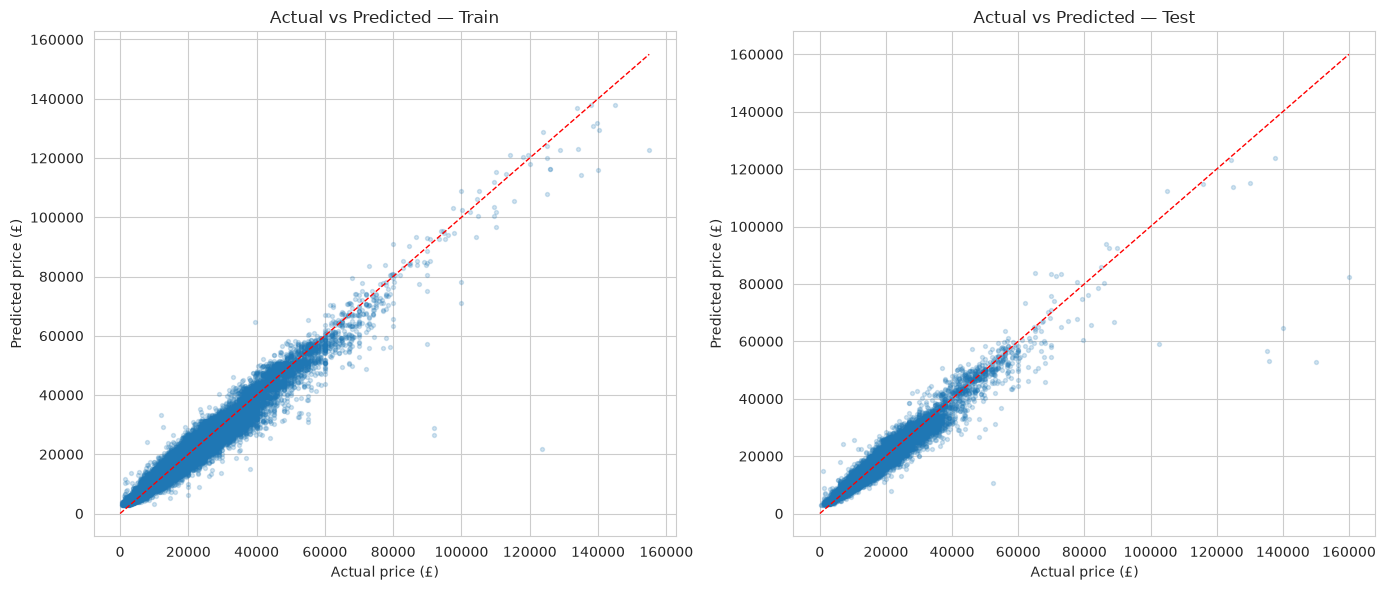

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (yt, yp, title) in zip(
    axes, [(y_train, pred_train, "Train"), (y_test, pred_test, "Test")]
):
    ax.scatter(yt, yp, alpha=0.2, s=8)
    lims = [0, max(yt.max(), yp.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("Actual price (£)")
    ax.set_ylabel("Predicted price (£)")
    ax.set_title(f"Actual vs Predicted — {title}")
plt.tight_layout()
plt.show()

---
## 7. Feature importance

engineSize      0.310332
transmission    0.209781
year            0.157243
mileage         0.100700
mpg             0.062434
manufacturer    0.050167
model           0.045198
tax             0.044527
fuelType        0.019618
dtype: float64


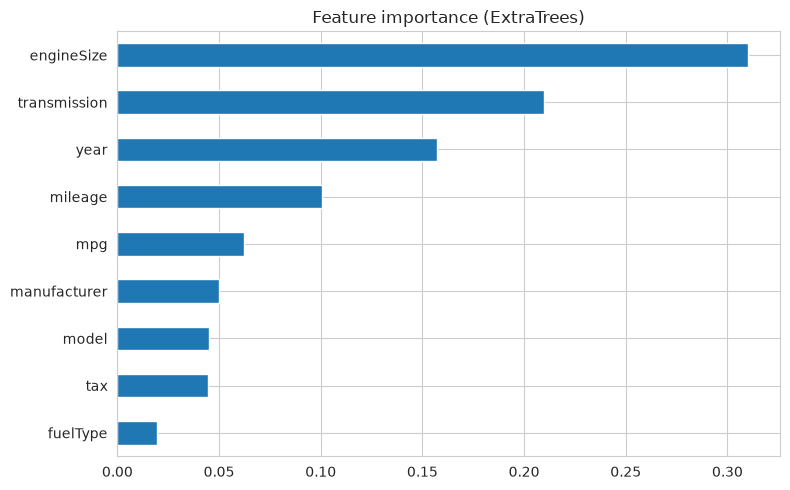

In [8]:
feat_names = [
    n.split("__", 1)[-1]
    for n in final_pipeline.named_steps["preprocessor"].get_feature_names_out()
]
importances = (
    pd.Series(final_pipeline.named_steps["model"].feature_importances_, index=feat_names)
    .sort_values(ascending=False)
)
print(importances)

importances.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature importance (ExtraTrees)")
plt.tight_layout()
plt.show()

---
## 8. Save the fitted pipeline (versioned)

In [9]:
version = "v1"
save_dir = f"outputs/ml_pipeline/predict_price/{version}"
os.makedirs(save_dir, exist_ok=True)
path = f"{save_dir}/pipeline.pkl"
joblib.dump(final_pipeline, path)
size_mb = os.path.getsize(path) / 1e6
print(f"Saved pipeline to {path} ({size_mb:.1f} MB)")

Saved pipeline to outputs/ml_pipeline/predict_price/v1/pipeline.pkl (7.2 MB)


## 9. Conclusions

**Algorithm.** A model comparison (section 3) showed the tree ensembles clearly beat a
single decision tree and gradient boosting. RandomForest and ExtraTrees were near-identical;
**ExtraTreesRegressor** was chosen as its randomised splits make the large search faster.

**Tuning.** A `GridSearchCV` over **six hyperparameters × three values each** (729
combinations, 3-fold CV, 2,187 fits) selected a deliberately *capped* model to keep it small
and deployable and to control overfitting:

- n_estimators = 50
- max_depth = 20
- max_leaf_nodes = 1000
- min_samples_leaf = 2
- min_samples_split = 5
- max_features = 1.0

Best cross-validated R² during the search: **0.906**.

**Performance on the full data:**

| Set   | R²    | MAE    | RMSE   |
|-------|-------|--------|--------|
| Train | 0.954 | £1,457 | £2,118 |
| Test  | 0.931 | £1,528 | £2,585 |

**Success metric — met.** The agreed target was **R² ≥ 0.80 on the unseen test set**; the
model achieves **R² = 0.931**, with an average error (MAE) of about **£1,528**. The small
train-test gap (0.954 vs 0.931) indicates the model generalises well rather than overfitting.

**Key price drivers** (feature importance): engineSize (0.31), transmission (0.21),
year (0.16) and mileage (0.10) dominate. This is consistent with the Correlation Study:
year, mileage and transmission were all validated hypotheses, and engineSize had the second
highest predictive power score.

**Output.** The fitted pipeline (encoding + model) is saved to
`outputs/ml_pipeline/predict_price/v1/pipeline.pkl` (**7.2 MB**) and powers the dashboard's
price predictor.

**Next:** build the Streamlit dashboard, then deploy to Heroku.
